# Week 2 Day 6 — Titanic v2 Full Pipeline

## What I built:
- Feature engineering: FamilySize, IsAlone, Title
- ColumnTransformer: median impute + scale numerics,
  mode impute + OneHotEncode categoricals
- Full Pipeline — no manual preprocessing, no leakage
- Evaluated with evaluate_model() function
- Final test set evaluation with classification report

## Results:
- CV Accuracy      : 0.8114 ± 0.0144
- CV F1 Score      : 0.7477
- Test Accuracy    : 0.81
- Kaggle Score     : 0.775

## Comparison vs Week 1:
- Week 1 Kaggle    : 0.782
- Week 2 Kaggle    : 0.775
- Slight drop — likely due to encoding differences
- Week 2 code is cleaner and production-ready

## Key improvements vs Week 1:
- Everything inside Pipeline — zero leakage possible
- ColumnTransformer handles numeric and categorical separately
- StratifiedKFold for reliable evaluation
- evaluate_model() reusable function

# Load data and define columns:

In [7]:
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import classification_report

df = pd.read_csv('train.csv')

# feature engineering first — outside pipeline
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone']    = (df['FamilySize'] == 1).astype(int)
df['Title']      = df['Name'].apply(
                       lambda name: name.split(',')[1]
                                        .split('.')[0].strip())
df['Title']      = df['Title'].map({
                       'Mr': 0, 'Miss': 1, 'Mrs': 2,
                       'Master': 3}).fillna(4)

# define features
num_cols = ['Age', 'Fare', 'FamilySize', 'Title']
cat_cols = ['Sex', 'Embarked', 'Pclass']

X = df[num_cols + cat_cols]
y = df['Survived']

print("X shape:", X.shape)
print("Missing values:\n", X.isnull().sum())

X shape: (891, 7)
Missing values:
 Age           177
Fare            0
FamilySize      0
Title           0
Sex             0
Embarked        2
Pclass          0
dtype: int64


# Build full ColumnTransformer Pipeline:

In [8]:
# numeric transformer
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

# categorical transformer
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# combine both
preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, num_cols),
    ('cat', cat_transformer, cat_cols)
])

# final pipeline
pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model',        LogisticRegression(max_iter=1000))
])

print("Pipeline built successfully")
print("\nSteps:")
for step in pipe.steps:
    print(f"  {step[0]} → {step[1]}")

Pipeline built successfully

Steps:
  preprocessor → ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['Age', 'Fare', 'FamilySize', 'Title']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['Sex', 'Embarked', 'Pclass'])])
  model → LogisticRegression(max_iter=1000)


# Evaluate with your evaluate_model() function:

In [9]:
import sys
sys.path.append('../')
from src.utils import evaluate_model

results = evaluate_model(pipe, X, y)

   MODEL EVALUATION
  Accuracy : 0.8114 ± 0.0144
  F1 Score : 0.7477


# Evaluate on held-out test set and submit to Kaggle:

   FINAL TEST SET EVALUATION
              precision    recall  f1-score   support

           0       0.83      0.87      0.85       110
           1       0.78      0.71      0.74        69

    accuracy                           0.81       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.81      0.81      0.81       179



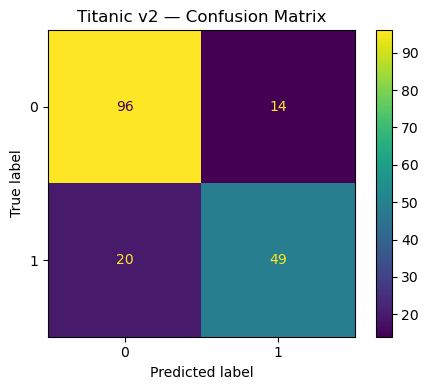

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# split — hold out 20% as final test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# fit on train only
pipe.fit(X_train, y_train)

# evaluate on test — first and only time
y_pred = pipe.predict(X_test)

print("=" * 45)
print("   FINAL TEST SET EVALUATION")
print("=" * 45)
print(classification_report(y_test, y_pred))

# confusion matrix
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_estimator(pipe, X_test, y_test, ax=ax)
plt.title('Titanic v2 — Confusion Matrix')
plt.tight_layout()
plt.savefig('titanic_v2_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Kaggle submission:

In [11]:
# load kaggle test data
test_df = pd.read_csv('test.csv')

# same feature engineering as train
test_df['FamilySize'] = test_df['SibSp'] + test_df['Parch'] + 1
test_df['IsAlone']    = (test_df['FamilySize'] == 1).astype(int)
test_df['Title']      = test_df['Name'].apply(
                            lambda name: name.split(',')[1]
                                             .split('.')[0].strip())
test_df['Title']      = test_df['Title'].map({
                            'Mr': 0, 'Miss': 1, 'Mrs': 2,
                            'Master': 3}).fillna(4)

X_kaggle = test_df[num_cols + cat_cols]

# fit pipeline on FULL train data then predict
pipe.fit(X, y)
predictions = pipe.predict(X_kaggle)

# create submission
submission = pd.DataFrame({
    'PassengerId': test_df['PassengerId'],
    'Survived':    predictions
})
submission.to_csv('submission_v2.csv', index=False)
print("Submission v2 saved!")
print(submission.head(10))

Submission v2 saved!
   PassengerId  Survived
0          892         0
1          893         0
2          894         0
3          895         0
4          896         1
5          897         0
6          898         1
7          899         0
8          900         1
9          901         0
